**This cell imports pandas, numpy, scipy.stats and matplotlib, brings in the backtest helpers from src/backtest.py, and loads everything I need to run the backtests.**

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.config import PROCESSED_DATA_DIR
from src.data_utils import read_panel
from src.backtest import (
    count_violations,               # boolean series: True on days where realized return < -VaR          # independence: do violations cluster in time or are they i.i.d.?
    diebold_mariano,                # forecast comparison: does method A outperform method B significantly?
    kupiec_summary,                 # summary table of Kupiec results across methods
    christoffersen_summary,         # summary table of Christoffersen results across methods
)

us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.parquet")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.parquet")["return"]

us_static_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_var_static_95.parquet")
us_static_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_var_static_99.parquet")
india_static_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_var_static_95.parquet")
india_static_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_var_static_99.parquet")

us_garch_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_garch_var_95.parquet")
us_garch_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_garch_var_99.parquet")
india_garch_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_garch_var_95.parquet")
india_garch_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_garch_var_99.parquet")

us_gjr_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_gjr_var_95.parquet")
us_gjr_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_gjr_var_99.parquet")
india_gjr_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_gjr_var_95.parquet")
india_gjr_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_gjr_var_99.parquet")

print('Done')


Done


**This cell calls count_violations for each of the 24 combinations: 2 markets × 6 methods × 2 confidence levels.** 

**A violation is a day where the realised return was worse than the VaR threshold predicted**

In [2]:
# US 95%
us_v_hist_95 = count_violations(us, us_static_95["historical_var"])         # 1 on days where us < -VaR, else 0
us_v_norm_95 = count_violations(us, us_static_95["normal_var"])
us_v_t_95 = count_violations(us, us_static_95["student_t_var"])
us_v_mc_95 = count_violations(us, us_static_95["monte_carlo_var"])
us_v_garch_95 = count_violations(us, us_garch_95["var"])
us_v_gjr_95 = count_violations(us, us_gjr_95["var"])

# US 99%
us_v_hist_99 = count_violations(us, us_static_99["historical_var"])
us_v_norm_99 = count_violations(us, us_static_99["normal_var"])
us_v_t_99 = count_violations(us, us_static_99["student_t_var"])
us_v_mc_99 = count_violations(us, us_static_99["monte_carlo_var"])
us_v_garch_99 = count_violations(us, us_garch_99["var"])
us_v_gjr_99 = count_violations(us, us_gjr_99["var"])

# India 95%
india_v_hist_95 = count_violations(india, india_static_95["historical_var"])        # 1 on days where india < -VaR, else 0
india_v_norm_95 = count_violations(india, india_static_95["normal_var"])
india_v_t_95 = count_violations(india, india_static_95["student_t_var"])
india_v_mc_95 = count_violations(india, india_static_95["monte_carlo_var"])
india_v_garch_95 = count_violations(india, india_garch_95["var"])
india_v_gjr_95 = count_violations(india, india_gjr_95["var"])

# India 99%
india_v_hist_99 = count_violations(india, india_static_99["historical_var"])
india_v_norm_99 = count_violations(india, india_static_99["normal_var"])
india_v_t_99 = count_violations(india, india_static_99["student_t_var"])
india_v_mc_99 = count_violations(india, india_static_99["monte_carlo_var"])
india_v_garch_99 = count_violations(india, india_garch_99["var"])
india_v_gjr_99 = count_violations(india, india_gjr_99["var"])

print("Done.")

Done.


**This cell groups the 24 violation series into four dictionaries (one per market × confidence level) and feeds each one into kupiec_summary, which runs the Kupiec test for each method and returns row per method. Stacking the four summaries into one combined table.** 

**The Kupiec test helps me answer the question: "Is the observed violation rate statistically consistent with the target rate (5% or 1%)?" and if a method passes, its violation count is in line with what the confidence level promises.**

In [3]:
us_viols_95 = {
    "Historical": us_v_hist_95, "Normal": us_v_norm_95, "Student-t": us_v_t_95,
    "Monte Carlo": us_v_mc_95, "GARCH": us_v_garch_95, "GJR-GARCH": us_v_gjr_95,
}
us_viols_99 = {
    "Historical": us_v_hist_99, "Normal": us_v_norm_99, "Student-t": us_v_t_99,
    "Monte Carlo": us_v_mc_99, "GARCH": us_v_garch_99, "GJR-GARCH": us_v_gjr_99,
}
india_viols_95 = {
    "Historical": india_v_hist_95, "Normal": india_v_norm_95, "Student-t": india_v_t_95,
    "Monte Carlo": india_v_mc_95, "GARCH": india_v_garch_95, "GJR-GARCH": india_v_gjr_95,
}
india_viols_99 = {
    "Historical": india_v_hist_99, "Normal": india_v_norm_99, "Student-t": india_v_t_99,
    "Monte Carlo": india_v_mc_99, "GARCH": india_v_garch_99, "GJR-GARCH": india_v_gjr_99,
}

kupiec_table = pd.concat([
    kupiec_summary(us_viols_95, 0.05, "US", "95%"),     # target violation rate is 1 - 0.95 = 5%
    kupiec_summary(us_viols_99, 0.01, "US", "99%"),     # target violation rate is 1 - 0.99 = 1%
    kupiec_summary(india_viols_95, 0.05, "India", "95%"),
    kupiec_summary(india_viols_99, 0.01, "India", "99%"),    
], ignore_index = True)

print(kupiec_table.to_string(index = False))

Market Level      Method  Expected  Actual  Rate %  Kupiec p-val Pass
    US   95%  Historical       188     195    5.17        0.6317 PASS
    US   95%      Normal       188     195    5.17        0.6317 PASS
    US   95%   Student-t       188     224    5.94        0.0100 FAIL
    US   95% Monte Carlo       188     191    5.06        0.8550 PASS
    US   95%       GARCH       176     187    5.31        0.4061 PASS
    US   95%   GJR-GARCH       176     199    5.65        0.0833 PASS
    US   99%  Historical        37      62    1.64        0.0003 FAIL
    US   99%      Normal        37      95    2.52        0.0000 FAIL
    US   99%   Student-t        37      69    1.83        0.0000 FAIL
    US   99% Monte Carlo        37      54    1.43        0.0123 FAIL
    US   99%       GARCH        35      92    2.61        0.0000 FAIL
    US   99%   GJR-GARCH        35      99    2.81        0.0000 FAIL
 India   95%  Historical       184     192    5.19        0.5917 PASS
 India   95%      No

**Findings:**
- At the 95% level, most methods pass. GARCH and Historical Simulation in particular tend to come in close to the target on both markets.
- At the 99% level, almost every method on both markets fails. The required rate is 1% but the observed rates are well above it.
- Normal VaR fails by the largest margin. The US Normal 99% rate hits about 2.5% because the Normal distribution is too thin-tailed to capture the actual frequency of extreme losses.
- Even GARCH and GJR-GARCH fail at 99%, despite adapting their volatility forecasts in real time. The reason is the Normal-innovation assumption so even when the variance forecast is correctly elevated, the standardised-residual tail is not fat enough to match the size of the largest losses that actually happen.

**This cell does the same but with the Christoffersen test.**

**Christoffersen helps answer a question: "Given that violations happen, are they independent in time, or do they cluster?"**

In [4]:
christoffersen_table = pd.concat([
    christoffersen_summary(us_viols_95, "US", "95%"),
    christoffersen_summary(us_viols_99, "US", "99%"),
    christoffersen_summary(india_viols_95, "India", "95%"),
    christoffersen_summary(india_viols_99, "India", "99%"),    
], ignore_index = True)

print(christoffersen_table.to_string(index = False))

Market Level      Method  Christ p-val Pass
    US   95%  Historical        0.0000 FAIL
    US   95%      Normal        0.0000 FAIL
    US   95%   Student-t        0.0000 FAIL
    US   95% Monte Carlo        0.0000 FAIL
    US   95%       GARCH        0.0010 FAIL
    US   95%   GJR-GARCH        0.0000 FAIL
    US   99%  Historical        0.0000 FAIL
    US   99%      Normal        0.0000 FAIL
    US   99%   Student-t        0.0016 FAIL
    US   99% Monte Carlo        0.0001 FAIL
    US   99%       GARCH        0.0001 FAIL
    US   99%   GJR-GARCH        0.0001 FAIL
 India   95%  Historical        0.0066 FAIL
 India   95%      Normal        0.0225 FAIL
 India   95%   Student-t        0.0007 FAIL
 India   95% Monte Carlo        0.0036 FAIL
 India   95%       GARCH        0.0014 FAIL
 India   95%   GJR-GARCH        0.0032 FAIL
 India   99%  Historical        0.2445 PASS
 India   99%      Normal        0.0006 FAIL
 India   99%   Student-t        0.9519 PASS
 India   99% Monte Carlo        

**Findings:**

- Most methods fail the Christoffersen test, including GARCH and GJR-GARCH at 95% on the US portfolio -> That means violations are bunching up in time rather than arriving independently.
- GARCH was built specifically to handle volatility clustering but still failed because (1) the model only refits its parameters every 21 days, so within each month the parameters are frozen and only the variance forecast updates, which creates a lag in regime changes. (2) Even with a correctly elevated variance forecast, the Normal-innovation assumption cannot match multi-day extreme moves.
- The static methods fail Christoffersen by larger margins than GARCH does -> That explains even though GARCH and GJR-GARCH model fails the test, it still responds to clustering better than the static methods


**This cell joins the Kupiec table and the Christoffersen table on (Market, Level, Method) so I get one row per method-market-level with both p-values and pass/fail flags side by side.**

In [5]:
#Merge both summary tables on the identifying columns (Market, Level, Method)
combined = kupiec_table.merge(
    christoffersen_table[["Market", "Level", "Method", "Christ p-val", "Pass"]].rename(columns = {"Pass": "Christ Pass"}),
    on = ["Market", "Level", "Method"]
)
combined = combined.rename(columns = {"Pass": "Kupiec Pass"})

print(combined.to_string(index = False))

Market Level      Method  Expected  Actual  Rate %  Kupiec p-val Kupiec Pass  Christ p-val Christ Pass
    US   95%  Historical       188     195    5.17        0.6317        PASS        0.0000        FAIL
    US   95%      Normal       188     195    5.17        0.6317        PASS        0.0000        FAIL
    US   95%   Student-t       188     224    5.94        0.0100        FAIL        0.0000        FAIL
    US   95% Monte Carlo       188     191    5.06        0.8550        PASS        0.0000        FAIL
    US   95%       GARCH       176     187    5.31        0.4061        PASS        0.0010        FAIL
    US   95%   GJR-GARCH       176     199    5.65        0.0833        PASS        0.0000        FAIL
    US   99%  Historical        37      62    1.64        0.0003        FAIL        0.0000        FAIL
    US   99%      Normal        37      95    2.52        0.0000        FAIL        0.0000        FAIL
    US   99%   Student-t        37      69    1.83        0.0000        F

**Findings:**

- **Not a single method clears both bars**, every row shows at least one FAIL across the two tests.
- At 95%, several methods pass Kupiec on both markets but every one of them fails Christoffersen, with p-values typically below 0.01. The right number of violations are happening, but they are clustering in time.
- At 99%, all methods fail Kupiec because the violation rate sits well above 1%, but several methods pass Christoffersen on India 99%. 
- The reason that in some methods but tests failed might come from the data I selected. The 30-ticker universe is smaller than the full index, the equal-weight construction differs from a market-cap portfolio, and using only currently-listed tickers introduces survivorship bias. So some of the failures may reflect the specific dataset rather than fundamental weakness in the methods.
- This shows that standard market-risk methods, even adaptive ones like GARCH, struggle to satisfy both correctness conditions simultaneously on real equity data.

**This cell runs the Diebold-Mariano test on a few specific method pairs at the 95% level.** 

**Diebold-Mariano answers: "Is method A's forecast significantly better than method B's, or could the difference be noise?"**

**I picked three comparisons that I think are the most informative:** 

**- GARCH vs GJR-GARCH (What is the effectiveness of the leverage effect?)**

**- GARCH vs Historical (Does the conditional model beat the simplest static method?)**

**- Historical vs Normal (Does using the empirical distribution beat a Normal fit?)**

In [6]:
print("US 95% comparisons:")
dm, p = diebold_mariano(us, us_garch_95["var"], us_gjr_95["var"])
print(f"  GARCH vs. GJR-GARCH:    DM={dm:.3f}, p={p:.4f}")         
dm, p = diebold_mariano(us, us_garch_95["var"], us_static_95["historical_var"])
print(f"  GARCH vs. Historical:   DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(us, us_static_95["historical_var"], us_static_95["normal_var"])
print(f"  Historical vs. Normal:  DM={dm:.3f}, p={p:.4f}")

print("\nIndia 95% comparisons:")
dm, p = diebold_mariano(india, india_garch_95["var"], india_gjr_95["var"])
print(f"  GARCH vs. GJR-GARCH:    DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(india, india_garch_95["var"], india_static_95["historical_var"])
print(f"  GARCH vs. Historical:   DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(india, india_static_95["historical_var"], india_static_95["normal_var"])
print(f"  Historical vs. Normal:  DM={dm:.3f}, p={p:.4f}")

US 95% comparisons:
  GARCH vs. GJR-GARCH:    DM=-1.426, p=0.1540
  GARCH vs. Historical:   DM=-1.340, p=0.1803
  Historical vs. Normal:  DM=-9.524, p=0.0000

India 95% comparisons:
  GARCH vs. GJR-GARCH:    DM=-3.460, p=0.0005
  GARCH vs. Historical:   DM=2.473, p=0.0134
  Historical vs. Normal:  DM=-7.945, p=0.0000


**Findings:**

- On India, GARCH significantly beats Historical. The conditional model is genuinely doing useful work that the static rolling-window cannot.
- On the US, the same GARCH vs Historical comparison is not statistically significant. The possible reason is that India's portfolio has lower volatility and lower kurtosis than the US portfolio, so distributional misspecification hurts the US tails more severely.
- GJR-GARCH was expected to beat vanilla GARCH because of the leverage effect: 
    + On the US it holds weakly. 
    + On India, GJR actually underperforms GARCH significantly, likely because the leverage effect is weak in this India portfolio and the extra parameter adds noise without adding signal.

**This cell defines a plotting helper that, given a violation dictionary for one (market, level) pair, draws one panel per method showing the realised return series in grey and the violation days as red dots.**

**Stacking the panels vertically lets me check whether violations cluster in time or look roughly evenly spread. I run it on all four (market, level) combinations.**

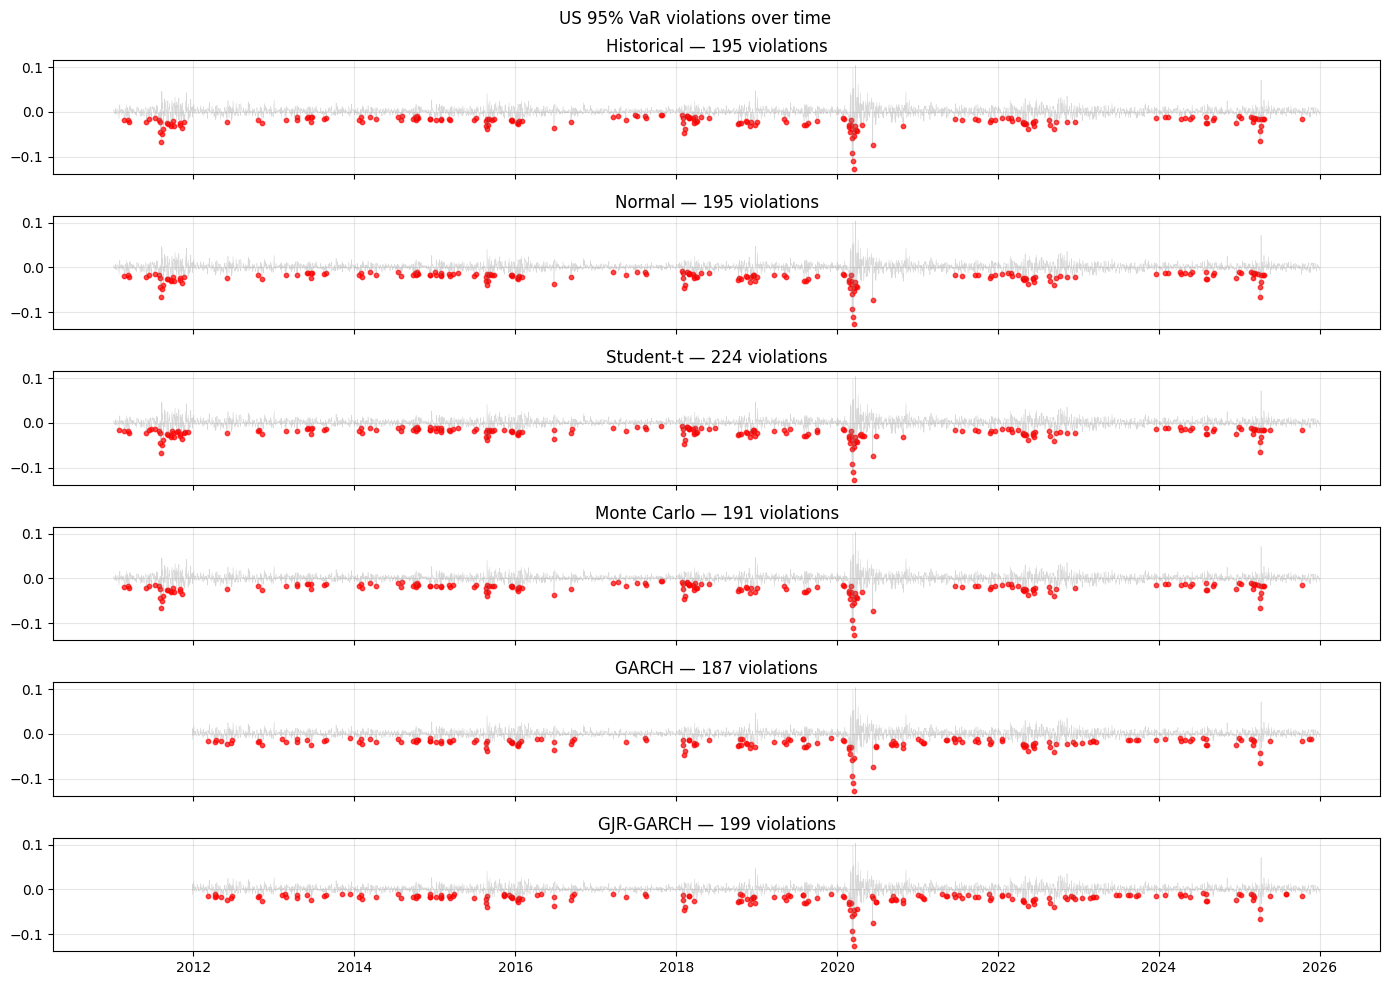

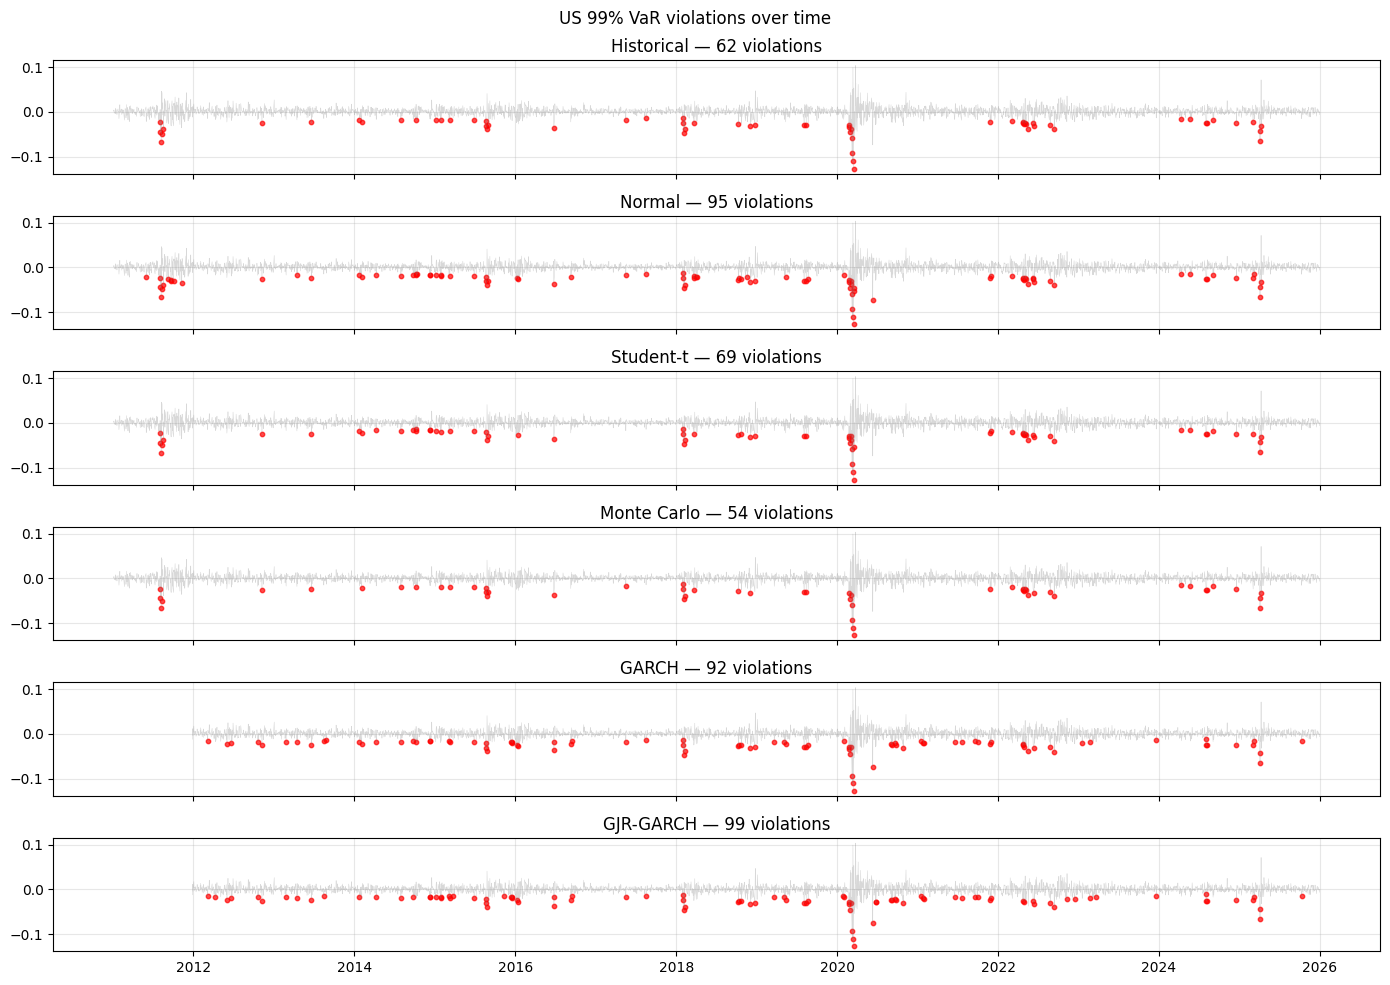

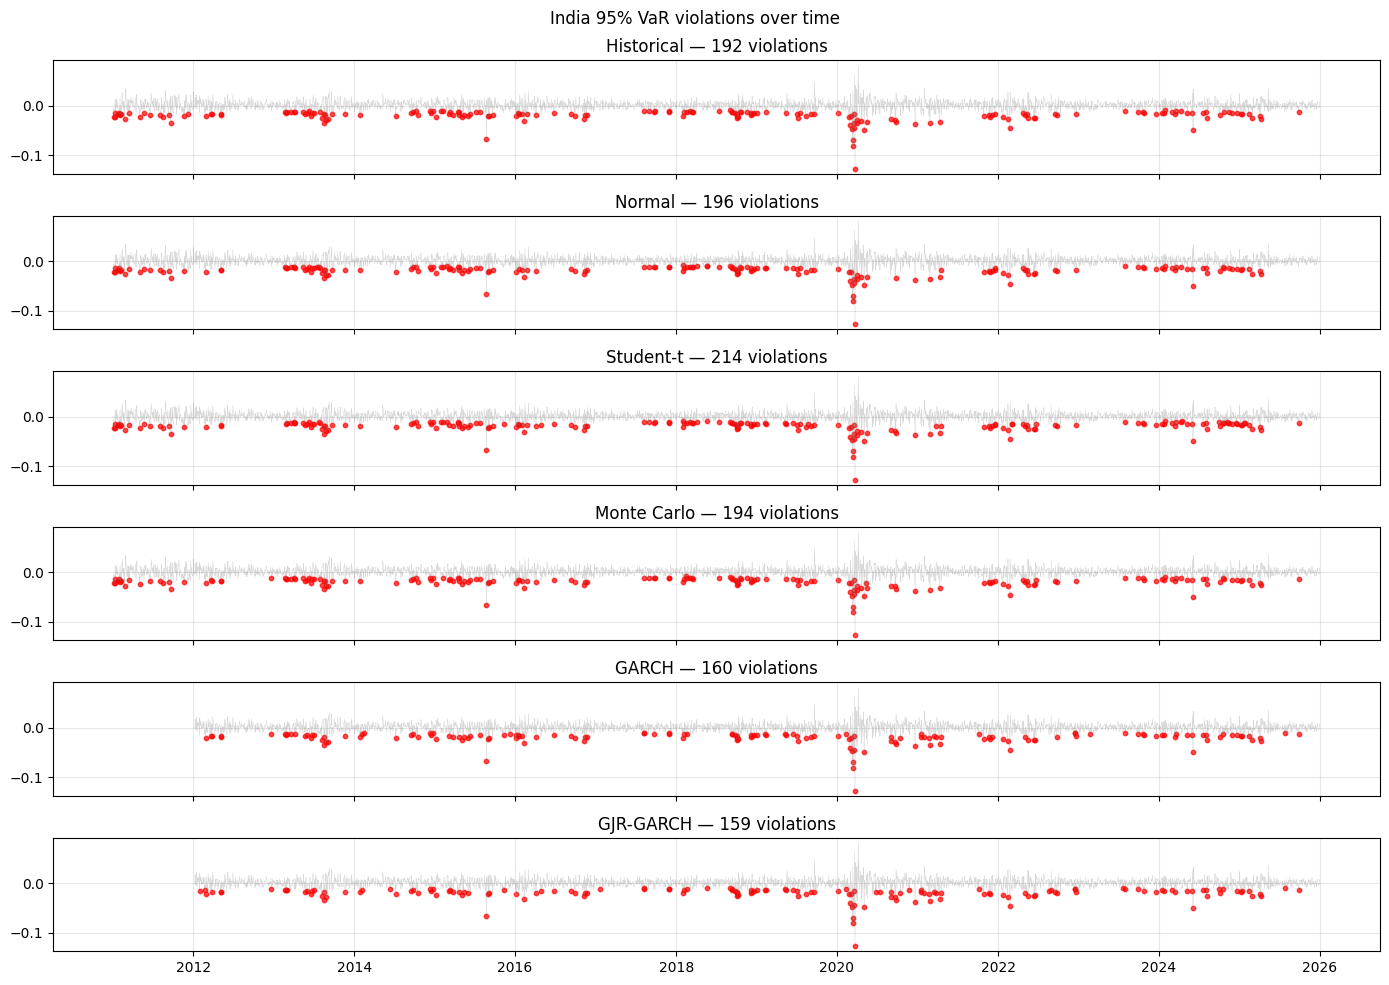

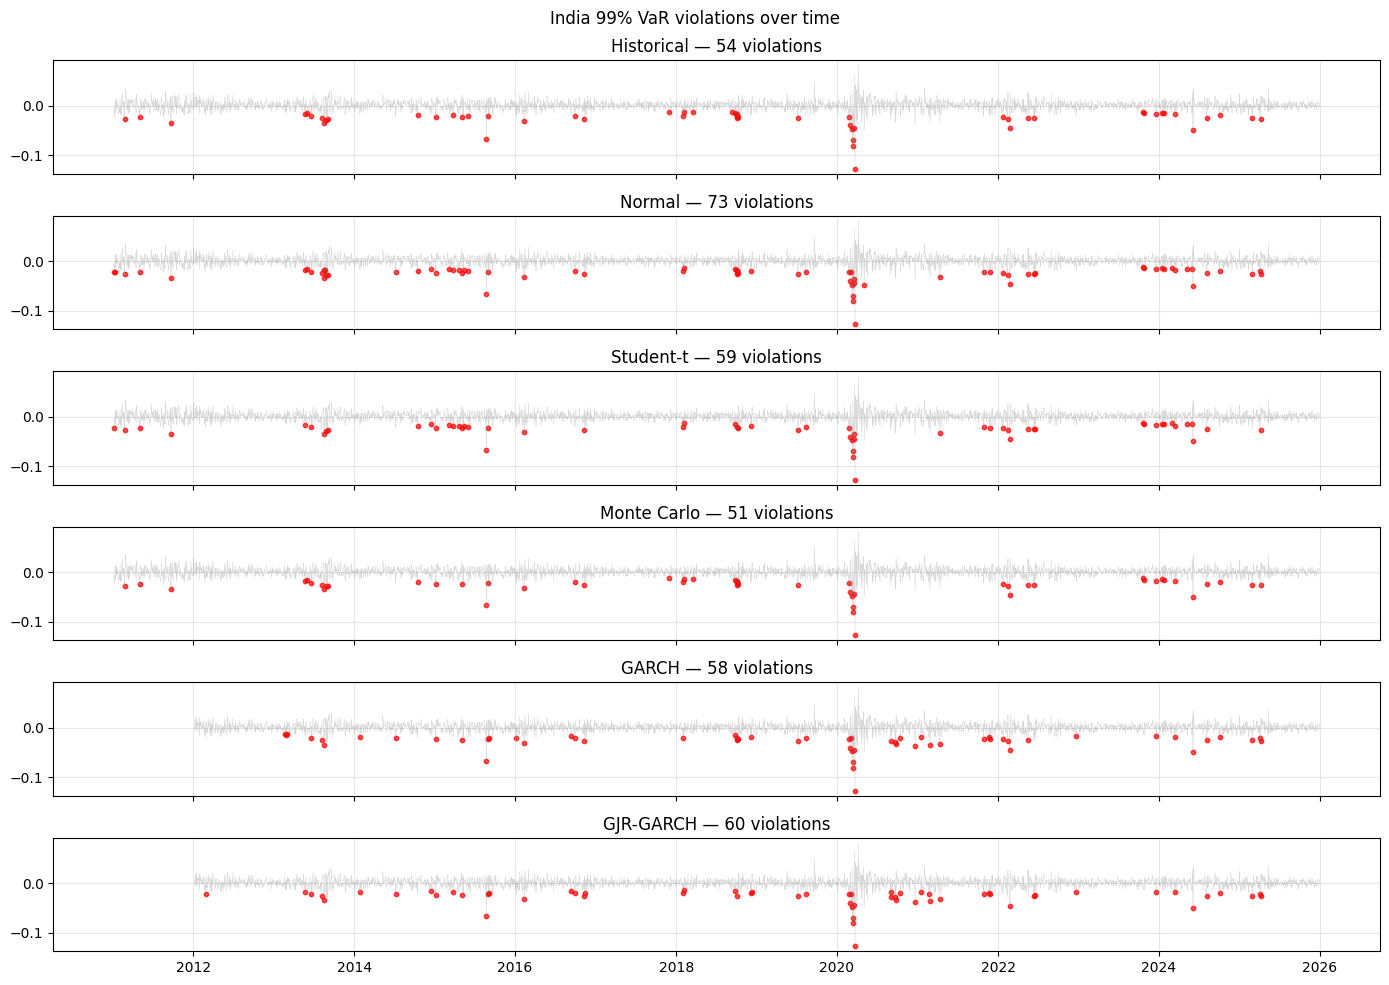

In [7]:
def plot_violation_timeline(returns, viol_dict, market, level):
    fig, axes = plt.subplots(len(viol_dict), 1, figsize=(14, 10), sharex=True)
    for ax, (method, v) in zip(axes, viol_dict.items()):  
        aligned_returns = returns.loc[v.index]
        ax.plot(aligned_returns.index, aligned_returns, color="gray", alpha=0.3, linewidth=0.4)
        viol_dates = v[v == 1].index
        ax.scatter(viol_dates, aligned_returns.loc[viol_dates], color="red", s=10, alpha=0.7)
        ax.set_title(f"{method} — {v.sum()} violations")
        ax.grid(alpha=0.3)
    plt.suptitle(f"{market} {level} VaR violations over time")
    plt.tight_layout()
    plt.show()


plot_violation_timeline(us, us_viols_95, "US", "95%")
plot_violation_timeline(us, us_viols_99, "US", "99%")
plot_violation_timeline(india, india_viols_95, "India", "95%")
plot_violation_timeline(india, india_viols_99, "India", "99%")

**Findings:**

- On the static method panels, red dots concentrate heavily around the COVID 2020 period. 
- A long stretch of violations bunched into one window is the visual signature of a Christoffersen failure.
- On the GARCH and GJR-GARCH panels, the red dots are visibly more spread out across time. Clusters still exist but they are less clustered than on the static methods.
- The 99% panels show many fewer red dots than the 95% panels as a deeper threshold is harder to breach, but the dots that do appear at 99% are almost all crisis-period events -> That is why 99% backtests are harder to pass you need a small absolute number of violations and you need them spread across time.

**This cell writes the merged Kupiec + Christoffersen table to data/processed/backtest_summary.parquet. Notebook 06 reads this file directly and renders it as one of the dashboard tables.**

In [8]:
combined.to_parquet(PROCESSED_DATA_DIR / "backtest_summary.parquet", index=False)
print("Saved.")

Saved.
